# Pairs Trading  Walkthrough


1. Construct a basket of 20 stocks.
2. Select more than one pair for monitoring from the **last 9 months of 2024** using
   - the distance method,
   - cointegration, and
   - Hurst exponent.
3. For each pair-selection method, run a **computer simulation from January to December 2025** using the selected pairs, then compare
   - cumulative P/L curves,
   - maximum drawdown, and
   - Sharpe ratio.

**Interpretation note:** The pair-selection formulas follow the lecture note. For the 2025 simulation step, the notebook uses one common hedge-ratio spread z-score engine so that the three pair-selection methods can be compared on a like-for-like basis.

**Sections:**
1. Stock Baskets and Time Windows
2. Distance Method
3. Cointegration (Engle-Granger)
4. Hurst Exponent
5. Backtest Engine for 2025 Simulation
6. US Market Backtest and Comparison
7. Taiwan Market Backtest and Comparison


In [1]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from hurst import compute_Hc
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8")

ADF_PVALUE_THRESHOLD = 0.05
HURST_MEAN_REVERSION_THRESHOLD = 0.5
N_PAIRS = 5
ENTRY_Z = 2.0
EXIT_Z = 0.5
STOP_Z = 4.0


def _exclusive_end_date(inclusive_end):
    inclusive = datetime.strptime(inclusive_end, "%Y-%m-%d")
    return (inclusive + timedelta(days=1)).strftime("%Y-%m-%d")


---
## 1. Stock Baskets and Time Windows

We keep the same **20-stock basket** for each market as the original walkthrough.

**Formation period for pair selection:** 2024-04-01 to 2024-12-31


**Trading period for simulation:** 2025-01-01 to 2025-12-31

The data download therefore covers both windows, while pair selection is always based on the 2024 formation sample.


In [2]:
US_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "META", "NVDA",
    "JPM", "GS", "BAC", "MS", "C",
    "KO", "PEP", "PG", "JNJ", "WMT",
    "XOM", "CVX", "COP", "NEE", "DUK",
]

TW_TICKERS = [
    "2330.TW", "2317.TW", "2454.TW", "2308.TW", "2303.TW",
    "3711.TW", "2382.TW", "3034.TW", "2881.TW", "2882.TW",
    "2891.TW", "2886.TW", "1301.TW", "1303.TW", "1326.TW",
    "2002.TW", "2412.TW", "1216.TW", "2912.TW", "2884.TW",
]

FORMATION_START = "2024-04-01"
FORMATION_END = "2024-12-31"
TRADING_START = "2025-01-01"
TRADING_END = "2025-12-31"
DOWNLOAD_END = _exclusive_end_date(TRADING_END)

us_data = yf.download(
    US_TICKERS,
    start=FORMATION_START,
    end=DOWNLOAD_END,
    auto_adjust=True,
    progress=False,
)
us_prices = us_data["Close"].dropna()
us_formation = us_prices[FORMATION_START:FORMATION_END]
us_trading = us_prices[TRADING_START:TRADING_END]

tw_data = yf.download(
    TW_TICKERS,
    start=FORMATION_START,
    end=DOWNLOAD_END,
    auto_adjust=True,
    progress=False,
)
tw_prices = tw_data["Close"].dropna()
tw_formation = tw_prices[FORMATION_START:FORMATION_END]
tw_trading = tw_prices[TRADING_START:TRADING_END]

print(f"US  formation: {us_formation.shape[0]} days, {us_formation.shape[1]} stocks")
print(f"US  trading:   {us_trading.shape[0]} days")
print(f"TW  formation: {tw_formation.shape[0]} days, {tw_formation.shape[1]} stocks")
print(f"TW  trading:   {tw_trading.shape[0]} days")


US  formation: 191 days, 20 stocks
US  trading:   250 days
TW  formation: 186 days, 20 stocks
TW  trading:   242 days


---
## 2. Distance Method

The lecture note standardizes each price series before comparison:

$$\widetilde{x}_i = \frac{x_i - \bar{X}}{\hat{X}}$$

and defines the pair distance as

$$d = \sum_{i=1}^{N} (\widetilde{x}_i - \widetilde{y}_i)^2.$$

Pairs with the **smallest** distance are selected as monitoring candidates. Since the task asks for more than one pair, we keep the top 5 pairs in each market.


US monitoring pairs by distance:
  GS/JPM: d = 9.20
  GS/MS: d = 15.25
  JPM/MS: d = 15.75
  BAC/MS: d = 19.24
  BAC/GS: d = 23.15

TW monitoring pairs by distance:
  1301.TW/1303.TW: d = 4.43
  1303.TW/1326.TW: d = 6.43
  1301.TW/1326.TW: d = 6.60
  2881.TW/2882.TW: d = 8.67
  2330.TW/2882.TW: d = 20.11


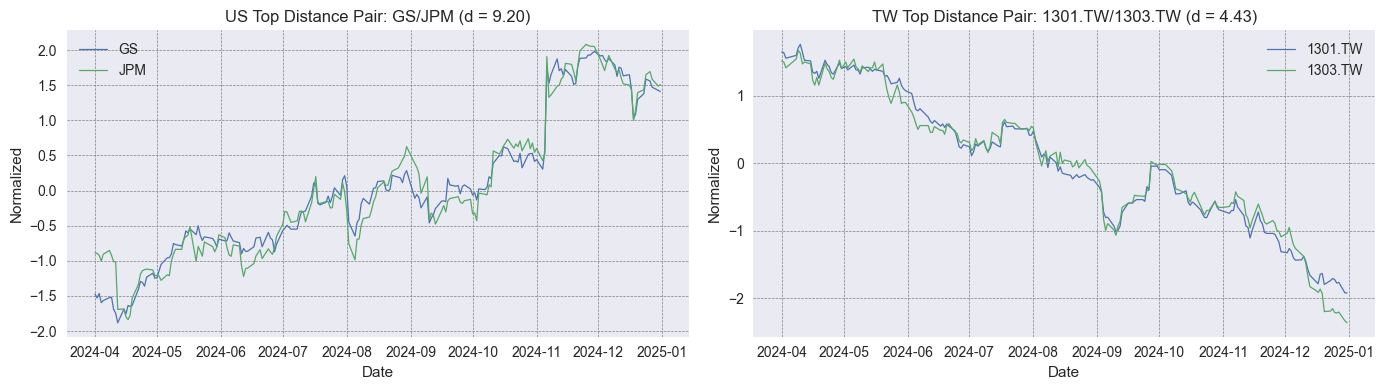

In [3]:
def select_pairs_distance(prices, n_pairs):
    tickers = list(prices.columns)
    normalized = (prices - prices.mean()) / prices.std(ddof=0)
    vals = normalized.values
    pairs = []
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            d = np.sum((vals[:, i] - vals[:, j]) ** 2)
            pairs.append((tickers[i], tickers[j], d))
    pairs.sort(key=lambda x: x[2])
    return pairs[:n_pairs]


us_dist_pairs = select_pairs_distance(us_formation, N_PAIRS)
tw_dist_pairs = select_pairs_distance(tw_formation, N_PAIRS)

print("US monitoring pairs by distance:")
for a, b, d in us_dist_pairs:
    print(f"  {a}/{b}: d = {d:.2f}")

print("\nTW monitoring pairs by distance:")
for a, b, d in tw_dist_pairs:
    print(f"  {a}/{b}: d = {d:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, prices, pair, title in [
    (axes[0], us_formation, us_dist_pairs[0], "US Top Distance Pair"),
    (axes[1], tw_formation, tw_dist_pairs[0], "TW Top Distance Pair"),
]:
    a, b, d = pair
    normalized = (prices - prices.mean()) / prices.std(ddof=0)
    ax.plot(normalized.index, normalized[a], linewidth=0.9, label=a)
    ax.plot(normalized.index, normalized[b], linewidth=0.9, label=b)
    ax.set(title=f"{title}: {a}/{b} (d = {d:.2f})", xlabel="Date", ylabel="Normalized")
    ax.legend()
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")

plt.tight_layout()
plt.show()


---
## 3. Cointegration (Engle-Granger)

For two price series $X_t$ and $Y_t$, estimate

$$X_t = c + \alpha Y_t + \epsilon_t.$$

If the residual $\epsilon_t$ is stationary, the pair is considered cointegrated. We use the **ADF test**, keep only pairs with `p <= 0.05`, and rank the qualified pairs by the ADF statistic from most negative upward.


US monitoring pairs by cointegration:
  GS/JPM: ADF = -4.1044, p = 0.0010
  JPM/WMT: ADF = -3.6097, p = 0.0056
  AAPL/COP: ADF = -3.5463, p = 0.0069
  PG/WMT: ADF = -3.5437, p = 0.0069
  CVX/KO: ADF = -3.3107, p = 0.0144

TW monitoring pairs by cointegration:
  2886.TW/3034.TW: ADF = -4.0317, p = 0.0013
  1216.TW/2881.TW: ADF = -3.3608, p = 0.0124
  2454.TW/2891.TW: ADF = -3.2715, p = 0.0162
  1303.TW/2002.TW: ADF = -3.2426, p = 0.0176
  2884.TW/2912.TW: ADF = -3.0826, p = 0.0279


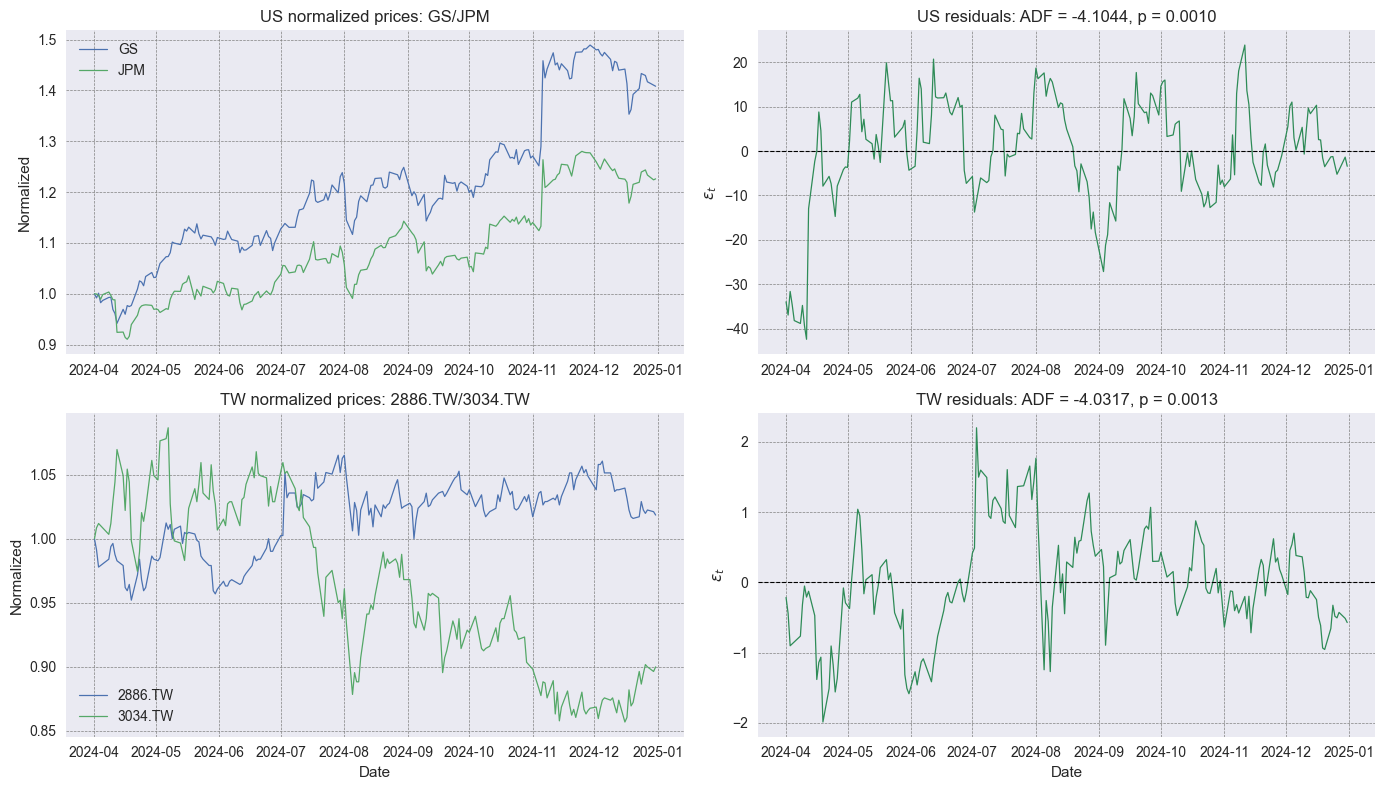

In [4]:
def select_pairs_cointegration(prices, n_pairs):
    tickers = list(prices.columns)
    pairs = []
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            pa = prices.iloc[:, i].values
            pb = prices.iloc[:, j].values
            result = OLS(pa, add_constant(pb)).fit()
            adf_stat, p_value, _, _, _, _ = adfuller(result.resid)
            if p_value <= ADF_PVALUE_THRESHOLD:
                pairs.append((tickers[i], tickers[j], adf_stat, p_value))
    pairs.sort(key=lambda x: (x[2], x[3]))
    return pairs[:n_pairs]


us_coint_pairs = select_pairs_cointegration(us_formation, N_PAIRS)
tw_coint_pairs = select_pairs_cointegration(tw_formation, N_PAIRS)

print("US monitoring pairs by cointegration:")
for a, b, adf, p in us_coint_pairs:
    print(f"  {a}/{b}: ADF = {adf:.4f}, p = {p:.4f}")

print("\nTW monitoring pairs by cointegration:")
for a, b, adf, p in tw_coint_pairs:
    print(f"  {a}/{b}: ADF = {adf:.4f}, p = {p:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, prices, pair, market in [
    (0, us_formation, us_coint_pairs[0], "US"),
    (1, tw_formation, tw_coint_pairs[0], "TW"),
]:
    a, b, adf, p = pair
    pa = prices[a].values
    pb = prices[b].values
    residuals = OLS(pa, add_constant(pb)).fit().resid
    axes[row, 0].plot(prices.index, pa / pa[0], linewidth=0.9, label=a)
    axes[row, 0].plot(prices.index, pb / pb[0], linewidth=0.9, label=b)
    axes[row, 0].set(title=f"{market} normalized prices: {a}/{b}", ylabel="Normalized")
    axes[row, 0].legend()
    axes[row, 0].grid(True, linestyle="--", linewidth=0.5, color="gray")
    axes[row, 1].plot(prices.index, residuals, color="seagreen", linewidth=0.9)
    axes[row, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[row, 1].set(title=f"{market} residuals: ADF = {adf:.4f}, p = {p:.4f}", ylabel=r"$\epsilon_t$")
    axes[row, 1].grid(True, linestyle="--", linewidth=0.5, color="gray")

axes[1, 0].set_xlabel("Date")
axes[1, 1].set_xlabel("Date")
plt.tight_layout()
plt.show()


---
## 4. Hurst Exponent

For a fractional Brownian motion, the Hurst exponent classifies persistence and mean reversion:

- $H = 0.5$: random walk
- $H > 0.5$: trending
- $H < 0.5$: mean-reverting

Following the lecture note, we compute the spread `X - Y`, keep only pairs with `H < 0.5`, and rank them from lowest H upward.


US monitoring pairs by Hurst exponent:
  GOOGL/MSFT: H = 0.3355
  BAC/PG: H = 0.3484
  NEE/PG: H = 0.3597
  BAC/C: H = 0.3828
  JNJ/KO: H = 0.3831

TW monitoring pairs by Hurst exponent:
  2317.TW/2382.TW: H = 0.3951
  2382.TW/3711.TW: H = 0.3989
  1301.TW/3034.TW: H = 0.4096
  2412.TW/2884.TW: H = 0.4113
  2382.TW/2882.TW: H = 0.4154


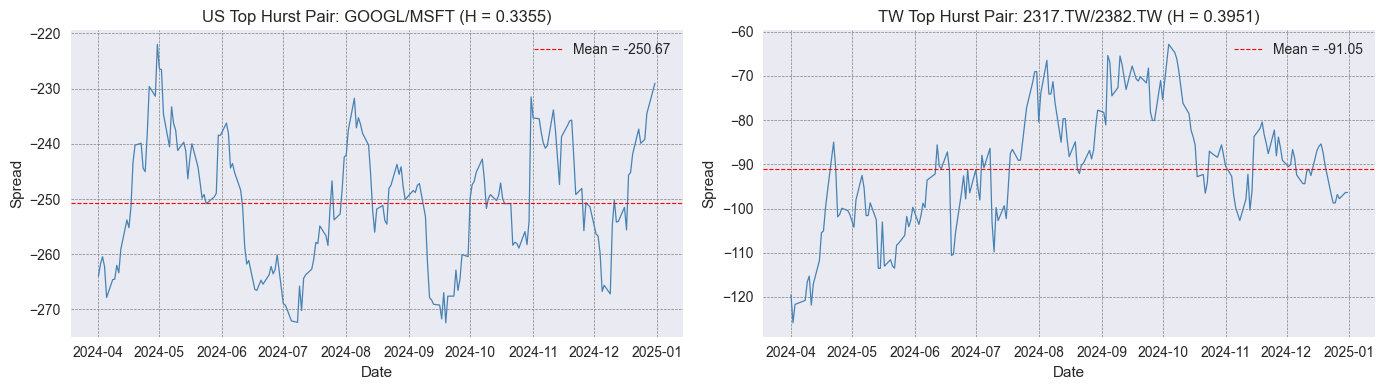

In [5]:
def select_pairs_hurst(prices, n_pairs):
    tickers = list(prices.columns)
    pairs = []
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            spread = prices.iloc[:, i].values - prices.iloc[:, j].values
            if np.allclose(spread, spread[0]):
                continue
            try:
                H, _, _ = compute_Hc(spread, kind="random_walk", simplified=True)
            except (FloatingPointError, ValueError):
                continue
            if H < HURST_MEAN_REVERSION_THRESHOLD:
                pairs.append((tickers[i], tickers[j], H))
    pairs.sort(key=lambda x: x[2])
    return pairs[:n_pairs]


us_hurst_pairs = select_pairs_hurst(us_formation, N_PAIRS)
tw_hurst_pairs = select_pairs_hurst(tw_formation, N_PAIRS)

print("US monitoring pairs by Hurst exponent:")
for a, b, H in us_hurst_pairs:
    print(f"  {a}/{b}: H = {H:.4f}")

print("\nTW monitoring pairs by Hurst exponent:")
for a, b, H in tw_hurst_pairs:
    print(f"  {a}/{b}: H = {H:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, prices, pair, title in [
    (axes[0], us_formation, us_hurst_pairs[0], "US Top Hurst Pair"),
    (axes[1], tw_formation, tw_hurst_pairs[0], "TW Top Hurst Pair"),
]:
    a, b, H = pair
    spread = prices[a].values - prices[b].values
    ax.plot(prices.index, spread, color="steelblue", linewidth=0.9)
    ax.axhline(np.mean(spread), color="red", linestyle="--", linewidth=0.8, label=f"Mean = {np.mean(spread):.2f}")
    ax.set(title=f"{title}: {a}/{b} (H = {H:.4f})", xlabel="Date", ylabel="Spread")
    ax.legend()
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")

plt.tight_layout()
plt.show()


---
## 5. Backtest Engine for 2025 Simulation

We now carry the selected pairs into the **2025 trading period**.

We use a common hedge-ratio spread z-score engine:

$$S_t = A_t - \beta B_t, \qquad z_t = \frac{S_t - \mu_S}{\sigma_S}$$

with the following rules:

- long spread when $z_t < -z_{\text{entry}}$
- short spread when $z_t > z_{\text{entry}}$
- take profit when $|z_t|$ returns inside $z_{\text{exit}}$
- stop loss when $|z_t|$ exceeds $z_{\text{stop}}$

This gives one consistent simulation framework for comparing the three pair-selection methods in 2025.


In [6]:
def backtest_pair(formation_a, formation_b, trading_a, trading_b,
                  entry_z, exit_z, stop_loss_z):
    fb_const = add_constant(formation_b)
    ols = OLS(formation_a, fb_const).fit()
    hedge_ratio = ols.params[1]

    formation_spread = formation_a - hedge_ratio * formation_b
    spread_mean = np.mean(formation_spread)
    spread_std = np.std(formation_spread)

    trading_spread = trading_a - hedge_ratio * trading_b
    z_scores = (trading_spread - spread_mean) / spread_std

    n = len(z_scores)
    positions = np.zeros(n)
    for t in range(1, n):
        prev = positions[t - 1]
        z = z_scores[t]
        if prev == 0:
            if z > entry_z:
                positions[t] = -1
            elif z < -entry_z:
                positions[t] = 1
        elif prev == 1:
            if z >= -exit_z or z <= -stop_loss_z:
                positions[t] = 0
            else:
                positions[t] = 1
        else:
            if z <= exit_z or z >= stop_loss_z:
                positions[t] = 0
            else:
                positions[t] = -1

    spread_changes = np.diff(trading_spread)
    daily_pnl = positions[:-1] * spread_changes / spread_std
    cumulative_pnl = np.cumsum(daily_pnl)

    equity = np.concatenate([[0], cumulative_pnl])
    peak = np.maximum.accumulate(equity)
    max_drawdown = np.max(peak - equity)
    sharpe = (
        np.mean(daily_pnl) / np.std(daily_pnl) * np.sqrt(252)
        if np.std(daily_pnl) > 0
        else 0.0
    )
    position_changes = int(np.sum(np.diff(positions) != 0))

    return {
        "pnl": cumulative_pnl,
        "daily_pnl": daily_pnl,
        "max_drawdown": max_drawdown,
        "sharpe": sharpe,
        "position_changes": position_changes,
        "z_scores": z_scores,
        "positions": positions,
        "hedge_ratio": hedge_ratio,
    }


def run_method_backtest(formation, trading, selected_pairs, entry_z, exit_z, stop_z):
    if not selected_pairs:
        return {
            "pairs": [],
            "aggregate_pnl": np.array([]),
            "aggregate_daily": np.array([]),
            "max_drawdown": 0.0,
            "sharpe": 0.0,
        }

    pair_results = []
    for ticker_a, ticker_b in selected_pairs:
        result = backtest_pair(
            formation[ticker_a].values,
            formation[ticker_b].values,
            trading[ticker_a].values,
            trading[ticker_b].values,
            entry_z,
            exit_z,
            stop_z,
        )
        result["pair"] = (ticker_a, ticker_b)
        pair_results.append(result)

    min_len = min(len(r["daily_pnl"]) for r in pair_results)
    daily_pnls = np.array([r["daily_pnl"][:min_len] for r in pair_results])
    agg_daily = np.sum(daily_pnls, axis=0)
    agg_pnl = np.cumsum(agg_daily)

    equity = np.concatenate([[0], agg_pnl])
    peak = np.maximum.accumulate(equity)
    max_dd = np.max(peak - equity)
    sharpe = (
        np.mean(agg_daily) / np.std(agg_daily) * np.sqrt(252)
        if np.std(agg_daily) > 0
        else 0.0
    )
    return {
        "pairs": pair_results,
        "aggregate_pnl": agg_pnl,
        "aggregate_daily": agg_daily,
        "max_drawdown": max_dd,
        "sharpe": sharpe,
    }


---
## 6. US Market Backtest and Comparison

We now backtest the selected US pairs during **January to December 2025**. The comparison is made method by method using cumulative P/L, maximum drawdown, and Sharpe ratio.


US monitoring pairs selected from Apr-Dec 2024:


,Distance,Cointegration,Hurst
Rank 1,GS/JPM,GS/JPM,GOOGL/MSFT
Rank 2,GS/MS,JPM/WMT,BAC/PG
Rank 3,JPM/MS,AAPL/COP,NEE/PG
Rank 4,BAC/MS,PG/WMT,BAC/C
Rank 5,BAC/GS,CVX/KO,JNJ/KO



Distance Method:
  GS/JPM: Sharpe=0.82, MaxDD=4.18, PositionChanges=51
  GS/MS: Sharpe=0.13, MaxDD=3.36, PositionChanges=114
  JPM/MS: Sharpe=-0.12, MaxDD=7.17, PositionChanges=147
  BAC/MS: Sharpe=1.79, MaxDD=4.80, PositionChanges=18
  BAC/GS: Sharpe=-0.97, MaxDD=8.32, PositionChanges=63

Cointegration Method:
  GS/JPM: Sharpe=0.82, MaxDD=4.18, PositionChanges=51
  JPM/WMT: Sharpe=0.45, MaxDD=5.40, PositionChanges=143
  AAPL/COP: Sharpe=-0.35, MaxDD=11.45, PositionChanges=83
  PG/WMT: Sharpe=-0.98, MaxDD=9.48, PositionChanges=136
  CVX/KO: Sharpe=-0.32, MaxDD=4.49, PositionChanges=29

Hurst Method:
  GOOGL/MSFT: Sharpe=-0.03, MaxDD=7.54, PositionChanges=83
  BAC/PG: Sharpe=-0.36, MaxDD=8.53, PositionChanges=123
  NEE/PG: Sharpe=0.76, MaxDD=4.73, PositionChanges=69
  BAC/C: Sharpe=-1.10, MaxDD=7.65, PositionChanges=187
  JNJ/KO: Sharpe=-0.24, MaxDD=7.20, PositionChanges=102

US Market - Aggregate Performance
Method             Sharpe    Max DD  Final PnL
------------------------------

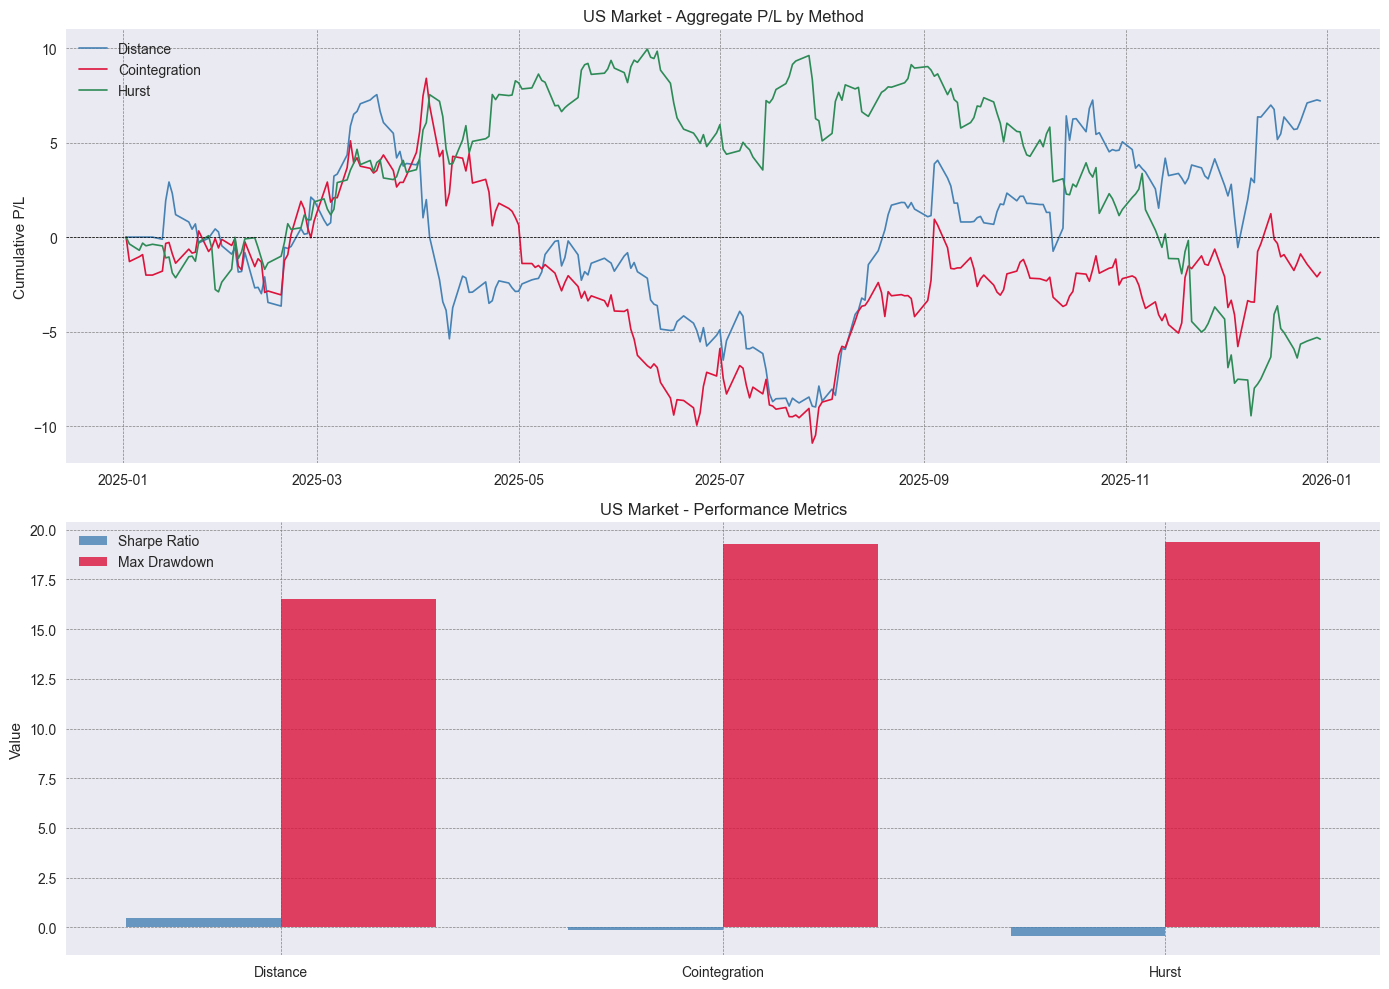

In [7]:
us_methods = {
    "Distance": [(p[0], p[1]) for p in us_dist_pairs],
    "Cointegration": [(p[0], p[1]) for p in us_coint_pairs],
    "Hurst": [(p[0], p[1]) for p in us_hurst_pairs],
}

us_monitoring = pd.DataFrame({
    "Distance": [f"{a}/{b}" for a, b in us_methods["Distance"]],
    "Cointegration": [f"{a}/{b}" for a, b in us_methods["Cointegration"]],
    "Hurst": [f"{a}/{b}" for a, b in us_methods["Hurst"]],
})
us_monitoring.index = [f"Rank {i}" for i in range(1, len(us_monitoring) + 1)]
print("US monitoring pairs selected from Apr-Dec 2024:")
display(us_monitoring)

us_results = {}
for name, pairs in us_methods.items():
    us_results[name] = run_method_backtest(us_formation, us_trading, pairs, ENTRY_Z, EXIT_Z, STOP_Z)

for name, res in us_results.items():
    print(f"\n{name} Method:")
    if not res["pairs"]:
        print("  No qualifying pairs selected.")
        continue
    for pr in res["pairs"]:
        a, b = pr["pair"]
        print(
            f"  {a}/{b}: Sharpe={pr['sharpe']:.2f}, "
            f"MaxDD={pr['max_drawdown']:.2f}, "
            f"PositionChanges={pr['position_changes']}"
        )

print("\n" + "=" * 55)
print("US Market - Aggregate Performance")
print(f"{'Method':<16} {'Sharpe':>8} {'Max DD':>9} {'Final PnL':>10}")
print("-" * 48)
for name, res in us_results.items():
    final = res["aggregate_pnl"][-1] if len(res["aggregate_pnl"]) > 0 else 0.0
    print(f"{name:<16} {res['sharpe']:>8.2f} {res['max_drawdown']:>9.2f} {final:>10.2f}")

colors = {"Distance": "steelblue", "Cointegration": "crimson", "Hurst": "seagreen"}
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for name, res in us_results.items():
    pnl = res["aggregate_pnl"]
    n_plot = min(len(pnl), len(us_trading.index))
    axes[0].plot(us_trading.index[:n_plot], pnl[:n_plot], color=colors[name], linewidth=1.2, label=name)
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.5)
axes[0].set(title="US Market - Aggregate P/L by Method", ylabel="Cumulative P/L")
axes[0].legend()
axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

method_names = list(us_results.keys())
sharpes = [us_results[m]["sharpe"] for m in method_names]
drawdowns = [us_results[m]["max_drawdown"] for m in method_names]
x = np.arange(len(method_names))
w = 0.35
axes[1].bar(x - w / 2, sharpes, w, label="Sharpe Ratio", color="steelblue", alpha=0.8)
axes[1].bar(x + w / 2, drawdowns, w, label="Max Drawdown", color="crimson", alpha=0.8)
axes[1].set(title="US Market - Performance Metrics", ylabel="Value", xticks=x, xticklabels=method_names)
axes[1].legend()
axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()


---
## 7. Taiwan Market Backtest and Comparison

Finally, we repeat the same 2025 simulation and comparison for the Taiwan basket.


Taiwan monitoring pairs selected from Apr-Dec 2024:


,Distance,Cointegration,Hurst
Rank 1,1301.TW/1303.TW,2886.TW/3034.TW,2317.TW/2382.TW
Rank 2,1303.TW/1326.TW,1216.TW/2881.TW,2382.TW/3711.TW
Rank 3,1301.TW/1326.TW,2454.TW/2891.TW,1301.TW/3034.TW
Rank 4,2881.TW/2882.TW,1303.TW/2002.TW,2412.TW/2884.TW
Rank 5,2330.TW/2882.TW,2884.TW/2912.TW,2382.TW/2882.TW



Distance Method:
  1301.TW/1303.TW: Sharpe=-1.28, MaxDD=19.73, PositionChanges=118
  1303.TW/1326.TW: Sharpe=-2.14, MaxDD=16.82, PositionChanges=104
  1301.TW/1326.TW: Sharpe=0.30, MaxDD=3.32, PositionChanges=14
  2881.TW/2882.TW: Sharpe=1.98, MaxDD=2.09, PositionChanges=13
  2330.TW/2882.TW: Sharpe=0.38, MaxDD=9.50, PositionChanges=115

Cointegration Method:
  2886.TW/3034.TW: Sharpe=2.10, MaxDD=3.88, PositionChanges=54
  1216.TW/2881.TW: Sharpe=0.40, MaxDD=4.69, PositionChanges=63
  2454.TW/2891.TW: Sharpe=0.29, MaxDD=3.79, PositionChanges=29
  1303.TW/2002.TW: Sharpe=-0.36, MaxDD=11.11, PositionChanges=106
  2884.TW/2912.TW: Sharpe=-0.93, MaxDD=8.84, PositionChanges=189

Hurst Method:
  2317.TW/2382.TW: Sharpe=-0.14, MaxDD=3.62, PositionChanges=27
  2382.TW/3711.TW: Sharpe=0.16, MaxDD=3.33, PositionChanges=67
  1301.TW/3034.TW: Sharpe=0.18, MaxDD=2.95, PositionChanges=7
  2412.TW/2884.TW: Sharpe=-1.15, MaxDD=12.96, PositionChanges=117
  2382.TW/2882.TW: Sharpe=0.94, MaxDD=2.92, Pos

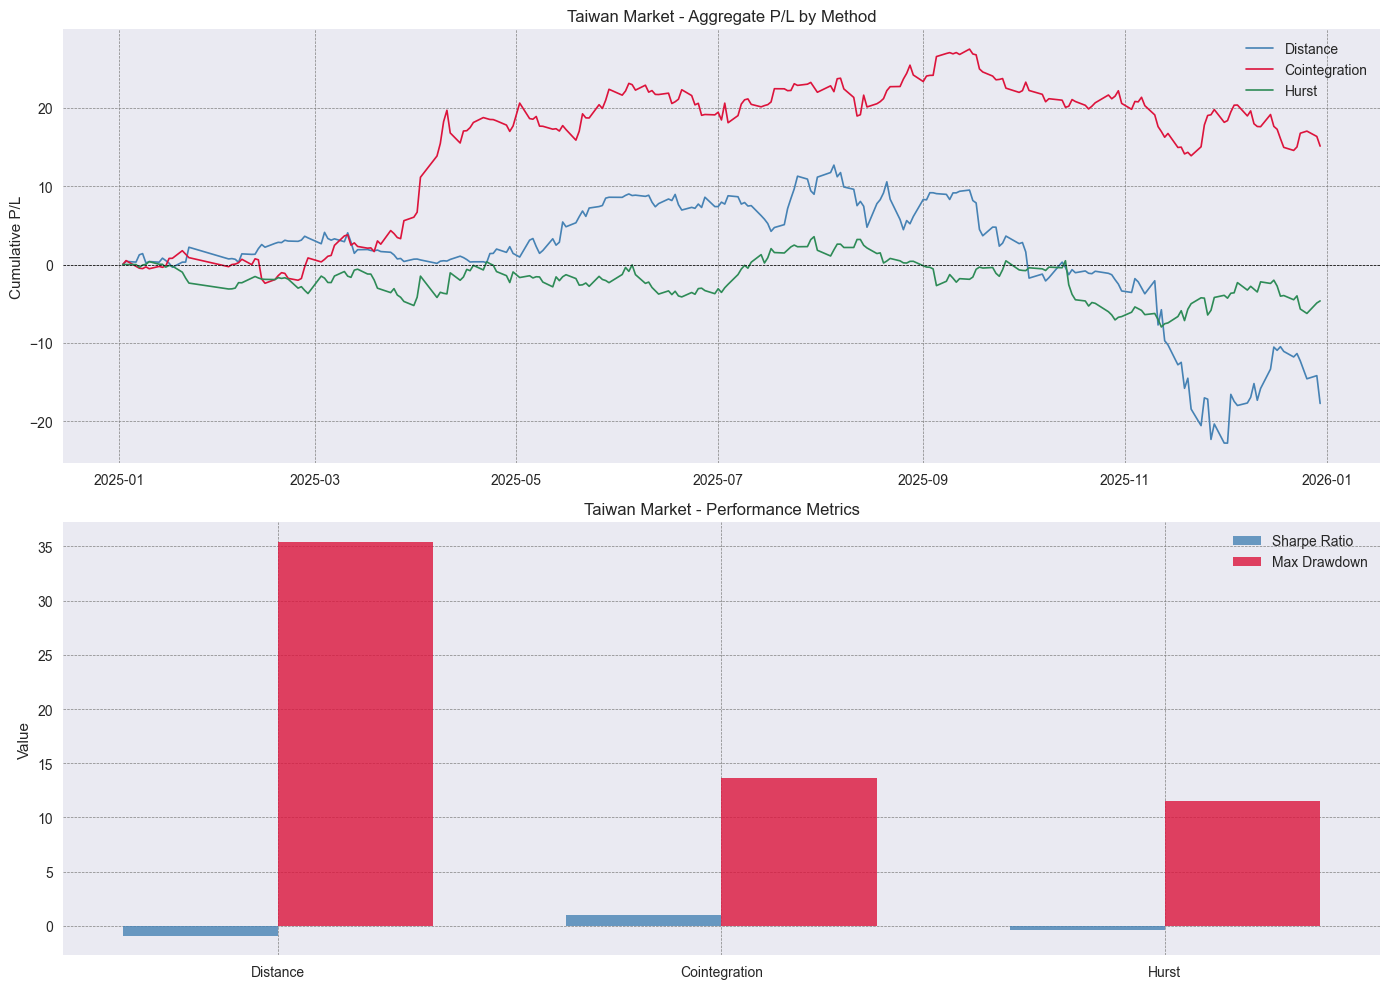

In [8]:
tw_methods = {
    "Distance": [(p[0], p[1]) for p in tw_dist_pairs],
    "Cointegration": [(p[0], p[1]) for p in tw_coint_pairs],
    "Hurst": [(p[0], p[1]) for p in tw_hurst_pairs],
}

tw_monitoring = pd.DataFrame({
    "Distance": [f"{a}/{b}" for a, b in tw_methods["Distance"]],
    "Cointegration": [f"{a}/{b}" for a, b in tw_methods["Cointegration"]],
    "Hurst": [f"{a}/{b}" for a, b in tw_methods["Hurst"]],
})
tw_monitoring.index = [f"Rank {i}" for i in range(1, len(tw_monitoring) + 1)]
print("Taiwan monitoring pairs selected from Apr-Dec 2024:")
display(tw_monitoring)

tw_results = {}
for name, pairs in tw_methods.items():
    tw_results[name] = run_method_backtest(tw_formation, tw_trading, pairs, ENTRY_Z, EXIT_Z, STOP_Z)

for name, res in tw_results.items():
    print(f"\n{name} Method:")
    if not res["pairs"]:
        print("  No qualifying pairs selected.")
        continue
    for pr in res["pairs"]:
        a, b = pr["pair"]
        print(
            f"  {a}/{b}: Sharpe={pr['sharpe']:.2f}, "
            f"MaxDD={pr['max_drawdown']:.2f}, "
            f"PositionChanges={pr['position_changes']}"
        )

print("\n" + "=" * 60)
print("Taiwan Market - Aggregate Performance")
print(f"{'Method':<16} {'Sharpe':>8} {'Max DD':>9} {'Final PnL':>10}")
print("-" * 48)
for name, res in tw_results.items():
    final = res["aggregate_pnl"][-1] if len(res["aggregate_pnl"]) > 0 else 0.0
    print(f"{name:<16} {res['sharpe']:>8.2f} {res['max_drawdown']:>9.2f} {final:>10.2f}")

colors = {"Distance": "steelblue", "Cointegration": "crimson", "Hurst": "seagreen"}
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for name, res in tw_results.items():
    pnl = res["aggregate_pnl"]
    n_plot = min(len(pnl), len(tw_trading.index))
    axes[0].plot(tw_trading.index[:n_plot], pnl[:n_plot], color=colors[name], linewidth=1.2, label=name)
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.5)
axes[0].set(title="Taiwan Market - Aggregate P/L by Method", ylabel="Cumulative P/L")
axes[0].legend()
axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

method_names = list(tw_results.keys())
sharpes = [tw_results[m]["sharpe"] for m in method_names]
drawdowns = [tw_results[m]["max_drawdown"] for m in method_names]
x = np.arange(len(method_names))
w = 0.35
axes[1].bar(x - w / 2, sharpes, w, label="Sharpe Ratio", color="steelblue", alpha=0.8)
axes[1].bar(x + w / 2, drawdowns, w, label="Max Drawdown", color="crimson", alpha=0.8)
axes[1].set(title="Taiwan Market - Performance Metrics", ylabel="Value", xticks=x, xticklabels=method_names)
axes[1].legend()
axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()
